# ❤️ Heart Disease Prediction — Advanced Machine Learning Project

## End-to-End ML Research Workflow

This notebook upgrades the existing Heart Disease UCI project into a more advanced, reproducible machine-learning workflow.

### Workflow

**Data Validation → Deep EDA → Statistical Signal Analysis → Feature Engineering → Leakage-Safe Preprocessing → PCA → Multi-Method Feature Selection → Baseline Models → Cross-Validation → Hyperparameter Optimization → Imbalance Experiments → Advanced Evaluation → Error Analysis → Explainability → Unsupervised Learning → Robustness → Final Pipeline → Export**

> **Medical disclaimer:** Educational/research use only. This project is not a clinical diagnostic system and must not be used to make medical decisions.

## 1. Environment & Configuration

The notebook is intentionally reproducible and uses a fixed random seed. Optional libraries such as XGBoost and SHAP are handled gracefully so the core notebook remains runnable.

In [41]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, f_oneway, skew, kurtosis
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import (
    RFE, SelectKBest, chi2, f_classif, mutual_info_classif
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Environment ready.")

Environment ready.


## 2. Load the Existing Clean Dataset

In [42]:
DATA_CANDIDATES = [
    Path("heart_disease_clean.csv"),
    Path("data/heart_disease_clean.csv"),
    Path("../data/heart_disease_clean.csv"),
    Path("/mnt/data/heart_disease_clean.csv"),
    Path("/mnt/data/heart_disease_clean(1).csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "heart_disease_clean.csv was not found. "
        "Place it beside the notebook or inside data/."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())

Dataset: heart_disease_clean.csv
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0000,1.0000,1.0000,145.0000,233.0000,1.0000,2.0000,150.0000,0.0000,2.3000,3.0000,0.0000,6.0000,0
1,67.0000,1.0000,4.0000,160.0000,286.0000,0.0000,2.0000,108.0000,1.0000,1.5000,2.0000,3.0000,3.0000,1
2,67.0000,1.0000,4.0000,120.0000,229.0000,0.0000,2.0000,129.0000,1.0000,2.6000,2.0000,2.0000,7.0000,1
3,37.0000,1.0000,3.0000,130.0000,250.0000,0.0000,0.0000,187.0000,0.0000,3.5000,3.0000,0.0000,3.0000,0
4,41.0000,0.0000,2.0000,130.0000,204.0000,0.0000,2.0000,172.0000,0.0000,1.4000,1.0000,0.0000,3.0000,0


## 3. Data Validation & Quality Audit

In [43]:
TARGET = "target"

expected_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

missing_expected = [c for c in expected_columns if c not in df.columns]
extra_columns = [c for c in df.columns if c not in expected_columns]

print("Missing expected columns:", missing_expected)
print("Extra columns:", extra_columns)
print("Duplicate rows:", df.duplicated().sum())

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique": df.nunique()
}).sort_values("missing", ascending=False)

display(quality)

if missing_expected:
    raise ValueError("Dataset schema does not match the expected project dataset.")

assert set(df[TARGET].dropna().unique()).issubset({0, 1}), "Target must be binary."

Missing expected columns: []
Extra columns: []
Duplicate rows: 0


,dtype,missing,missing_pct,unique
age,float64,0,0.0000,41
sex,float64,0,0.0000,2
cp,float64,0,0.0000,4
trestbps,float64,0,0.0000,50
chol,float64,0,0.0000,152
fbs,float64,0,0.0000,2
restecg,float64,0,0.0000,3
thalach,float64,0,0.0000,91
exang,float64,0,0.0000,2
oldpeak,float64,0,0.0000,40


## 4. Target Distribution

,count,percentage
target,,
0,164,54.1254
1,139,45.8746


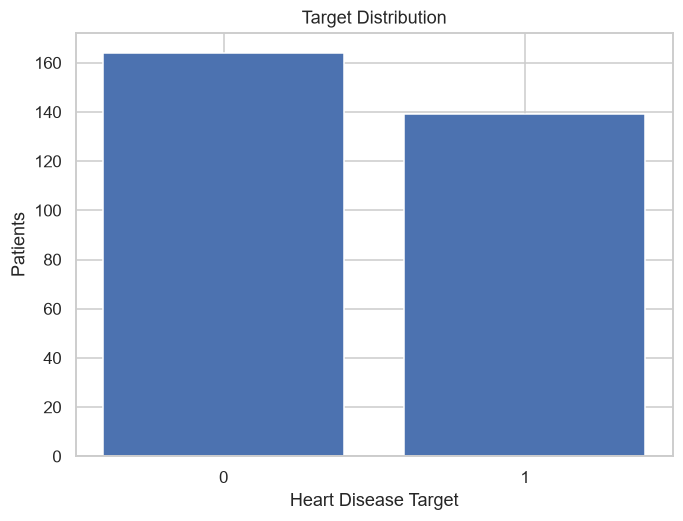

In [44]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct = df[TARGET].value_counts(normalize=True).sort_index().mul(100)

display(pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
}))

plt.figure(figsize=(7, 5))
counts = df[TARGET].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Target Distribution")
plt.xlabel("Heart Disease Target")
plt.ylabel("Patients")
plt.show()

## 5. Feature Types & Clinical Categorical Variables

In [45]:
X = df.drop(columns=TARGET)
y = df[TARGET].astype(int)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

clinical_categorical = [
    c for c in [
        "sex", "cp", "fbs", "restecg",
        "exang", "slope", "ca", "thal"
    ] if c in X.columns
]

continuous_features = [c for c in numeric_features if c not in clinical_categorical]

print("All predictors:", numeric_features)
print("Clinical categorical candidates:", clinical_categorical)
print("Continuous features:", continuous_features)

All predictors: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Clinical categorical candidates: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Continuous features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


## 6. Deep EDA — Distribution, Skewness & Kurtosis

,mean,median,std,skewness,kurtosis
fbs,0.1485,0.0000,0.3562,1.9768,1.9078
oldpeak,1.0396,0.8000,1.1611,1.2634,1.5302
ca,0.6634,0.0000,0.9344,1.2028,0.2828
chol,246.6931,241.0000,51.7769,1.1299,4.3982
cp,3.1584,3.0000,0.9601,-0.8376,-0.4138
sex,0.6799,1.0000,0.4673,-0.7711,-1.4054
exang,0.3267,0.0000,0.4698,0.7389,-1.4541
trestbps,131.6898,130.0000,17.5997,0.7025,0.8459
thalach,149.6073,153.0000,22.8750,-0.5348,-0.0724
slope,1.6007,2.0000,0.6162,0.5058,-0.6370


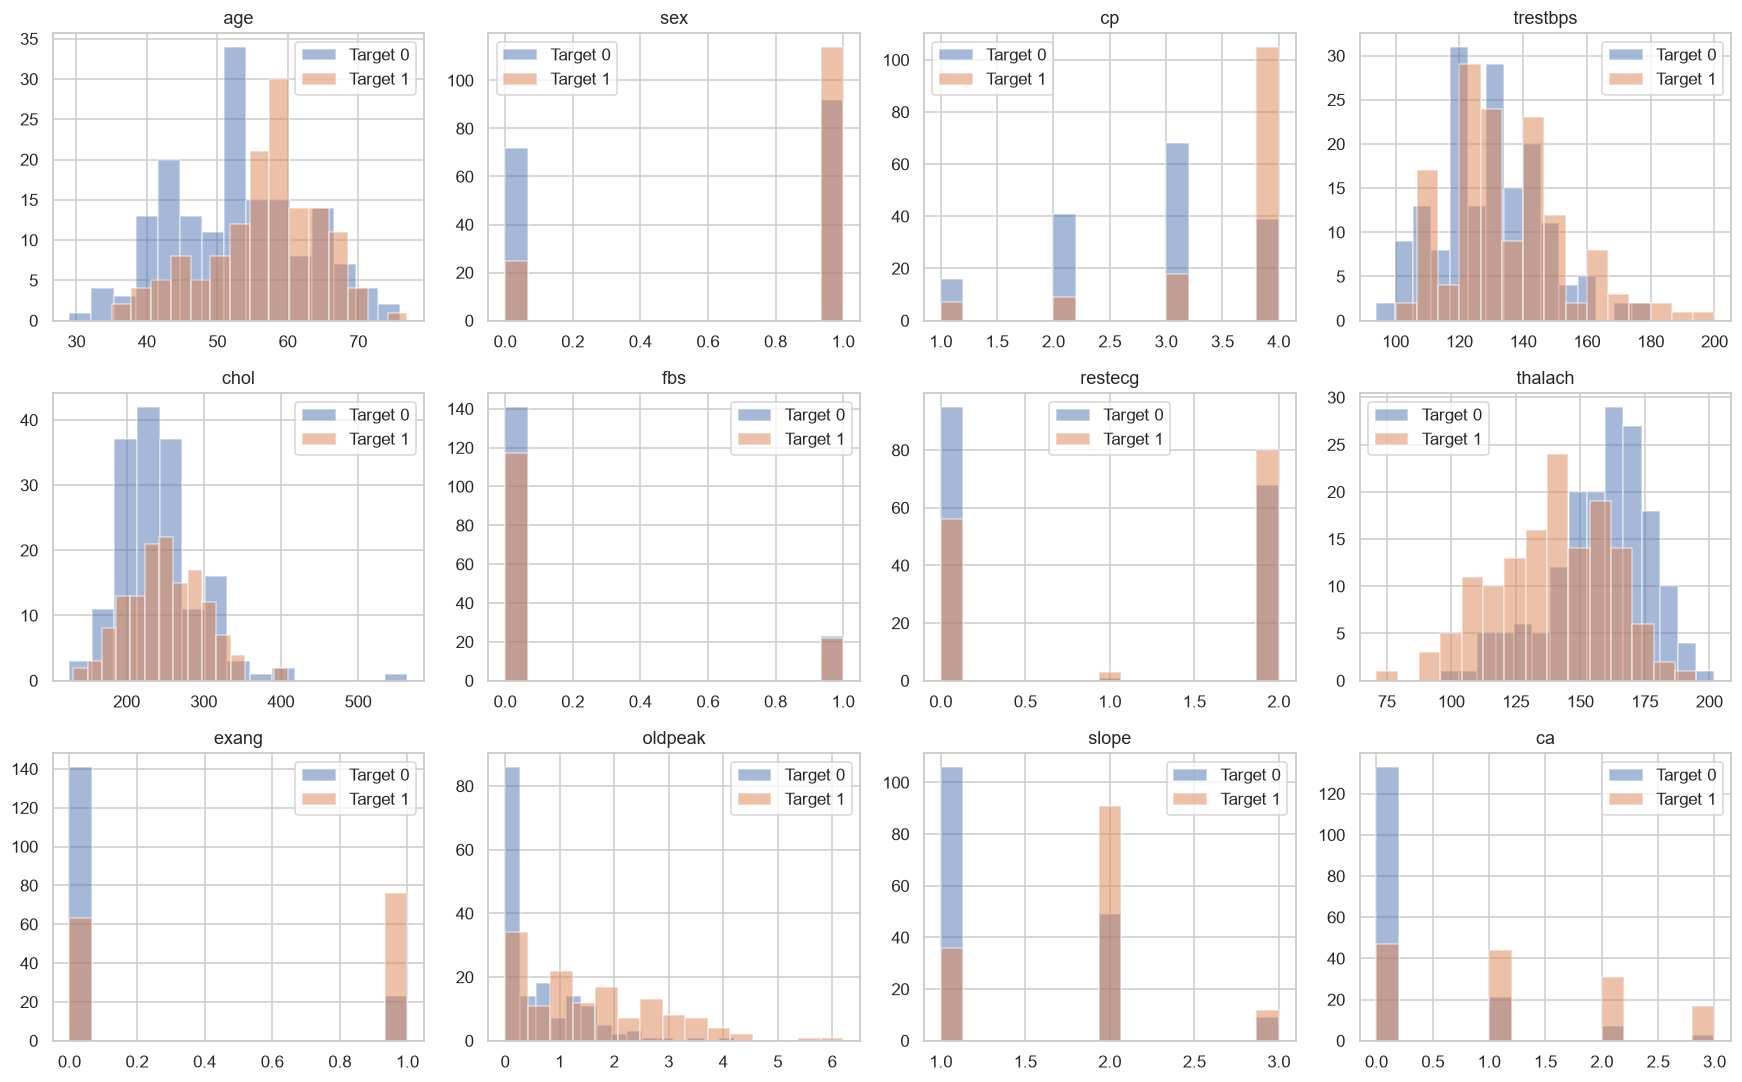

In [46]:
distribution_summary = pd.DataFrame({
    "mean": X[numeric_features].mean(),
    "median": X[numeric_features].median(),
    "std": X[numeric_features].std(),
    "skewness": X[numeric_features].apply(skew),
    "kurtosis": X[numeric_features].apply(kurtosis)
}).sort_values("skewness", key=lambda s: s.abs(), ascending=False)

display(distribution_summary)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, numeric_features):
    for target_value in sorted(df[TARGET].dropna().unique()):
        values = df.loc[df[TARGET] == target_value, feature].dropna()
        ax.hist(values, bins=15, alpha=0.5, label=f"Target {int(target_value)}")
    ax.set_title(feature)
    ax.legend()

for ax in axes[len(numeric_features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Outlier Audit — IQR Method

,feature,lower_bound,upper_bound,outlier_count,outlier_pct
1,trestbps,90.0000,170.0000,9,2.9703
4,oldpeak,-2.4000,4.0000,5,1.6502
2,chol,115.0000,371.0000,5,1.6502
3,thalach,84.7500,214.7500,1,0.3300
0,age,28.5000,80.5000,0,0.0000


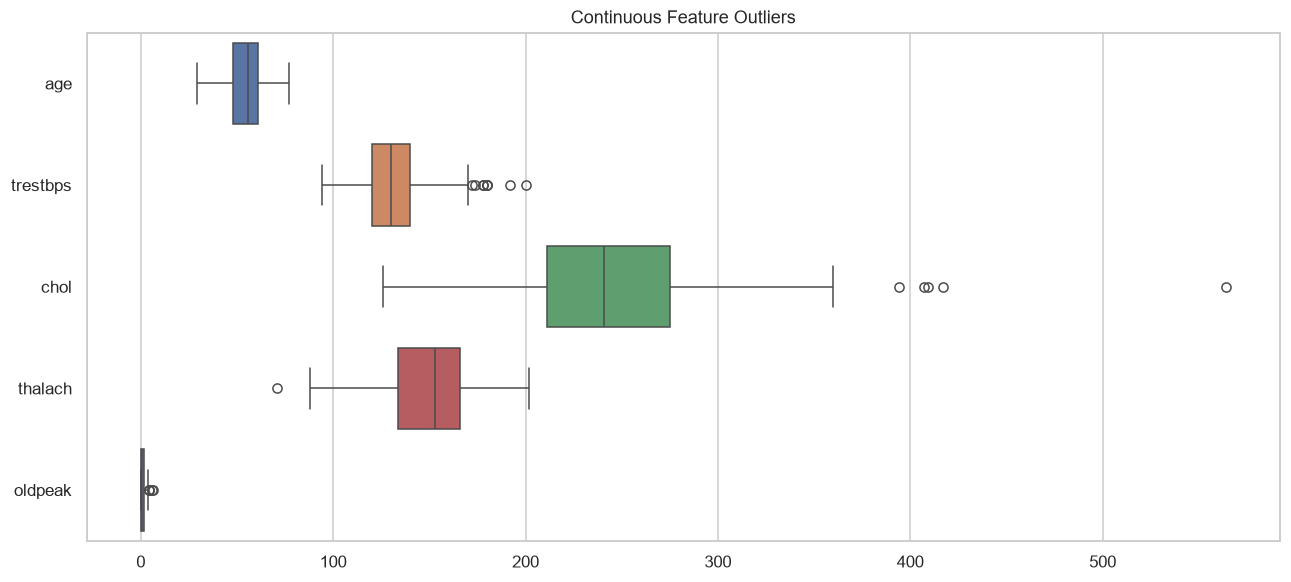

In [47]:
outlier_rows = []

for feature in continuous_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[feature] < lower) | (df[feature] > upper)).sum()
    outlier_rows.append([feature, lower, upper, count, count / len(df) * 100])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["feature", "lower_bound", "upper_bound", "outlier_count", "outlier_pct"]
).sort_values("outlier_count", ascending=False)

display(outlier_summary)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[continuous_features], orient="h")
plt.title("Continuous Feature Outliers")
plt.show()

## 8. Correlation & Multicollinearity

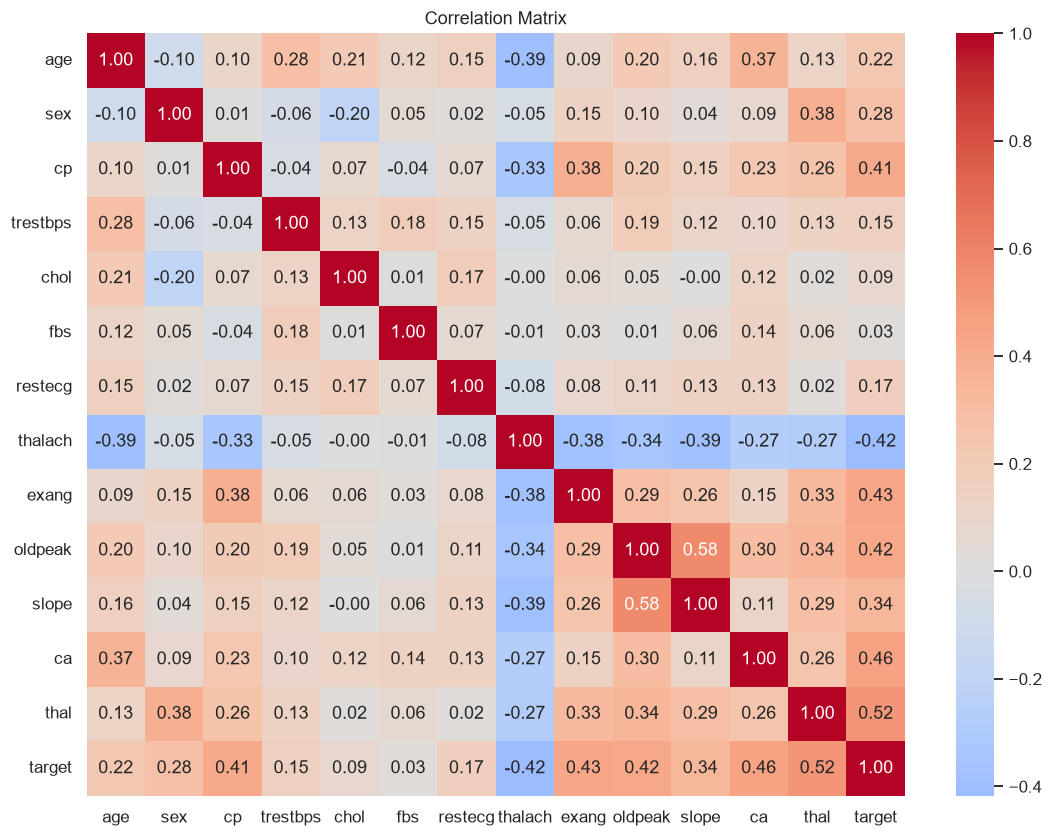

,absolute_target_correlation
thal,0.5221
ca,0.4600
exang,0.4319
oldpeak,0.4245
thalach,0.4172
cp,0.4144
slope,0.3392
sex,0.2768
age,0.2231
restecg,0.1692


In [48]:
corr = df[numeric_features + [TARGET]].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

target_corr = (
    corr[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .rename("absolute_target_correlation")
)

display(target_corr.to_frame())

In [49]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif_X = X[numeric_features].copy()
    vif = pd.DataFrame({
        "feature": vif_X.columns,
        "VIF": [
            variance_inflation_factor(vif_X.values, i)
            for i in range(vif_X.shape[1])
        ]
    }).sort_values("VIF", ascending=False)

    display(vif)
except ImportError:
    print("statsmodels is not installed; VIF analysis skipped.")

,feature,VIF
3,trestbps,60.8444
0,age,42.4783
7,thalach,34.6686
4,chol,26.3837
2,cp,13.5991
10,slope,11.7941
12,thal,10.4966
1,sex,3.8641
9,oldpeak,3.1301
6,restecg,2.1532


## 9. Statistical Signal Analysis

In [50]:
anova_rows = []

for feature in numeric_features:
    groups = [
        df.loc[df[TARGET] == cls, feature].dropna()
        for cls in sorted(df[TARGET].unique())
    ]
    if all(len(g) > 1 for g in groups):
        stat, p = f_oneway(*groups)
        anova_rows.append([feature, stat, p])

anova_results = pd.DataFrame(
    anova_rows,
    columns=["feature", "F_statistic", "p_value"]
).sort_values("p_value")

display(anova_results)

,feature,F_statistic,p_value
12,thal,112.7702,0.0000
11,ca,80.8006,0.0000
8,exang,69.0209,0.0000
9,oldpeak,66.1667,0.0000
7,thalach,63.4192,0.0000
2,cp,62.4238,0.0000
10,slope,39.1382,0.0000
1,sex,24.9789,0.0000
0,age,15.7696,0.0001
6,restecg,8.8714,0.0031


In [51]:
# Chi-square and Cramér's V for clinically categorical variables
chi_rows = []

for feature in clinical_categorical:
    table = pd.crosstab(df[feature], y)
    chi2_stat, p_value, dof, expected = chi2_contingency(table)

    n = table.values.sum()
    phi2 = chi2_stat / n
    r, k = table.shape

    # Bias-corrected Cramér's V
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    rcorr = r - ((r - 1) ** 2) / max(n - 1, 1)
    kcorr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denominator = min(kcorr - 1, rcorr - 1)

    cramers_v = np.sqrt(phi2corr / denominator) if denominator > 0 else 0

    chi_rows.append([feature, chi2_stat, p_value, cramers_v])

chi_results = pd.DataFrame(
    chi_rows,
    columns=["feature", "chi2", "p_value", "cramers_v"]
).sort_values("cramers_v", ascending=False)

display(chi_results)

,feature,chi2,p_value,cramers_v
7,thal,82.6845,0.0000,0.5169
1,cp,81.8158,0.0000,0.5108
6,ca,72.6169,0.0000,0.4801
4,exang,54.6864,0.0000,0.4216
5,slope,45.7846,0.0000,0.3807
0,sex,22.0426,0.0000,0.2639
3,restecg,10.0515,0.0066,0.1632
2,fbs,0.0771,0.7813,0.0000


## 10. Mutual Information

,feature,mutual_information
12,thal,0.1482
11,ca,0.1341
2,cp,0.1330
9,oldpeak,0.1247
8,exang,0.0964
10,slope,0.0873
4,chol,0.0794
7,thalach,0.0548
5,fbs,0.0382
1,sex,0.0235


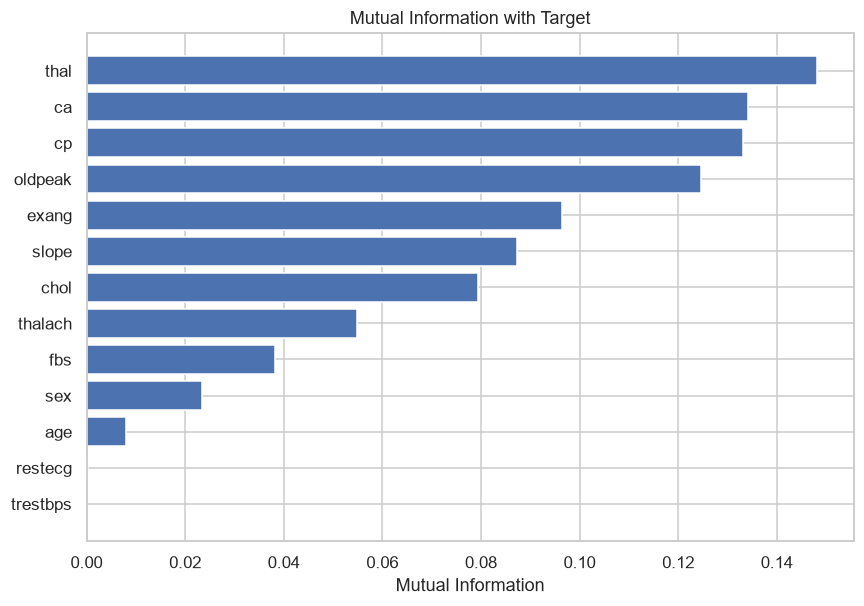

In [52]:
mi = mutual_info_classif(
    X[numeric_features],
    y,
    random_state=RANDOM_STATE
)

mi_results = (
    pd.DataFrame({"feature": numeric_features, "mutual_information": mi})
    .sort_values("mutual_information", ascending=False)
)

display(mi_results)

plt.figure(figsize=(9, 6))
mi_plot = mi_results.sort_values("mutual_information")
plt.barh(mi_plot["feature"], mi_plot["mutual_information"])
plt.xlabel("Mutual Information")
plt.title("Mutual Information with Target")
plt.show()

## 11. Feature Engineering

In [53]:
def add_engineered_features(data):
    out = data.copy()

    out["age_group"] = pd.cut(
        out["age"],
        bins=[0, 40, 50, 60, 70, 100],
        labels=False,
        include_lowest=True
    )

    out["thalach_age_ratio"] = out["thalach"] / out["age"].replace(0, np.nan)
    out["chol_age_ratio"] = out["chol"] / out["age"].replace(0, np.nan)
    out["bp_age_ratio"] = out["trestbps"] / out["age"].replace(0, np.nan)
    out["oldpeak_thalach_ratio"] = out["oldpeak"] / out["thalach"].replace(0, np.nan)

    out["exercise_stress_index"] = out["oldpeak"] * (1 + out["exang"])
    out["cardio_burden"] = out["ca"] + out["exang"] + out["oldpeak"]

    return out.replace([np.inf, -np.inf], np.nan)

X_engineered = add_engineered_features(X)

engineered_columns = [
    c for c in X_engineered.columns
    if c not in X.columns
]

print("Engineered features:", engineered_columns)
display(X_engineered.head())

Engineered features: ['age_group', 'thalach_age_ratio', 'chol_age_ratio', 'bp_age_ratio', 'oldpeak_thalach_ratio', 'exercise_stress_index', 'cardio_burden']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,age_group,thalach_age_ratio,chol_age_ratio,bp_age_ratio,oldpeak_thalach_ratio,exercise_stress_index,cardio_burden
0,63.0000,1.0000,1.0000,145.0000,233.0000,1.0000,2.0000,150.0000,0.0000,2.3000,3.0000,0.0000,6.0000,3,2.3810,3.6984,2.3016,0.0153,2.3000,2.3000
1,67.0000,1.0000,4.0000,160.0000,286.0000,0.0000,2.0000,108.0000,1.0000,1.5000,2.0000,3.0000,3.0000,3,1.6119,4.2687,2.3881,0.0139,3.0000,5.5000
2,67.0000,1.0000,4.0000,120.0000,229.0000,0.0000,2.0000,129.0000,1.0000,2.6000,2.0000,2.0000,7.0000,3,1.9254,3.4179,1.7910,0.0202,5.2000,5.6000
3,37.0000,1.0000,3.0000,130.0000,250.0000,0.0000,0.0000,187.0000,0.0000,3.5000,3.0000,0.0000,3.0000,0,5.0541,6.7568,3.5135,0.0187,3.5000,3.5000
4,41.0000,0.0000,2.0000,130.0000,204.0000,0.0000,2.0000,172.0000,0.0000,1.4000,1.0000,0.0000,3.0000,1,4.1951,4.9756,3.1707,0.0081,1.4000,1.4000


## 12. Leakage-Safe Train/Test Split

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print("Train target distribution:")
display(y_train.value_counts(normalize=True).rename("proportion"))

Train: (242, 20)
Test : (61, 20)
Train target distribution:


target
0   0.5413
1   0.4587
Name: proportion, dtype: float64

## 13. Leakage-Safe Preprocessing Pipelines

In [55]:
# Treat the original coded categorical variables as categorical.
categorical_features_engineered = [
    c for c in clinical_categorical if c in X_train.columns
] + (["age_group"] if "age_group" in X_train.columns else [])

numeric_features_engineered = [
    c for c in X_train.columns
    if c not in categorical_features_engineered
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features_engineered),
    ("cat", categorical_pipeline, categorical_features_engineered)
])

print("Numeric:", numeric_features_engineered)
print("Categorical:", categorical_features_engineered)

Numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'thalach_age_ratio', 'chol_age_ratio', 'bp_age_ratio', 'oldpeak_thalach_ratio', 'exercise_stress_index', 'cardio_burden']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'age_group']


## 14. PCA — Explained Variance & Dimensionality Reduction

,component,explained_variance,cumulative_variance
0,1,0.3175,0.3175
1,2,0.1531,0.4706
2,3,0.0905,0.5612
3,4,0.0759,0.6371
4,5,0.0648,0.7019
5,6,0.0538,0.7557
6,7,0.0473,0.8030
7,8,0.0445,0.8475
8,9,0.0422,0.8897
9,10,0.0320,0.9217


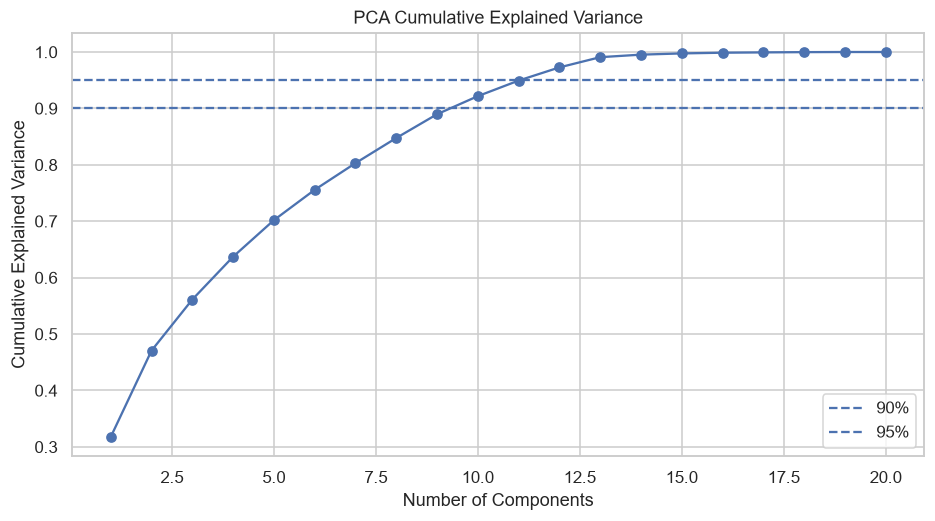

Components required for 95% variance: 12


In [56]:
pca_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_scaled = pca_preprocessor.fit_transform(X_train)
X_test_scaled = pca_preprocessor.transform(X_test)

pca_full = PCA()
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_summary = pd.DataFrame({
    "component": np.arange(1, len(explained) + 1),
    "explained_variance": explained,
    "cumulative_variance": cumulative
})

display(pca_summary)

plt.figure(figsize=(10, 5))
plt.plot(pca_summary["component"], pca_summary["cumulative_variance"], marker="o")
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print("Components required for 95% variance:", n_components_95)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
age,0.2556,-0.3948,0.0949,0.1426,-0.0073,-0.0109,-0.1223,-0.0648,-0.0784,0.1034,0.1437,0.0576
sex,0.0521,0.1579,-0.2896,0.0454,0.5183,-0.1069,-0.0801,-0.4761,-0.1946,0.0712,-0.2184,0.4284
cp,0.1555,0.0229,0.0172,-0.4333,0.2332,-0.0852,0.0082,0.5379,0.0684,-0.2224,0.3694,0.4710
trestbps,0.0936,0.0630,0.2611,0.5814,0.0975,-0.2120,-0.3344,0.3395,-0.1089,0.0600,-0.0542,0.0563
chol,0.0408,-0.0389,0.6802,-0.1722,0.0277,-0.0469,-0.1313,-0.2830,0.0401,-0.0050,0.0112,0.0717
fbs,0.0512,-0.0481,0.0471,0.3158,0.4029,0.2007,0.1948,-0.0571,0.7766,-0.1025,0.0178,0.0547
restecg,0.0700,-0.0165,0.2037,0.1610,0.1344,-0.3700,0.7814,0.0190,-0.3029,0.0748,0.0399,0.0750
thalach,-0.2786,0.0656,0.0779,0.2200,0.0215,0.2787,0.0677,-0.1355,-0.1081,0.2377,0.6473,0.0272
exang,0.2050,0.1592,-0.0314,-0.2638,0.2307,-0.2381,-0.0444,0.1191,0.1976,0.6929,0.0326,-0.3549
oldpeak,0.3083,0.2661,-0.0044,0.1094,-0.2560,0.1507,0.0169,-0.0946,-0.0093,-0.0120,0.0926,0.2131


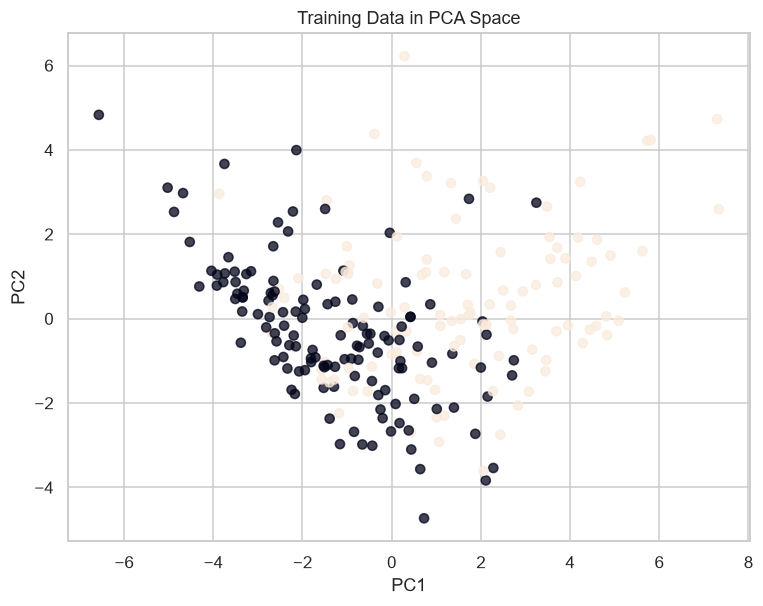

In [57]:
pca_95 = PCA(n_components=n_components_95)

X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

pca_feature_names = X_train.columns.tolist()

loadings = pd.DataFrame(
    pca_95.components_.T,
    index=pca_feature_names,
    columns=[f"PC{i+1}" for i in range(n_components_95)]
)

display(loadings)

if n_components_95 >= 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_train_pca[:, 0],
        X_train_pca[:, 1],
        c=y_train,
        alpha=0.75
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Training Data in PCA Space")
    plt.show()

## 15. Multi-Method Feature Selection

In [58]:
# Filter: ANOVA + Mutual Information + Chi-square
analysis_X = X[numeric_features].copy()

f_scores, f_p = f_classif(analysis_X, y)
mi_scores = mutual_info_classif(analysis_X, y, random_state=RANDOM_STATE)

chi_X = MinMaxScaler().fit_transform(analysis_X)
chi_scores, chi_p = chi2(chi_X, y)

filter_summary = pd.DataFrame({
    "feature": numeric_features,
    "anova_score": f_scores,
    "anova_p": f_p,
    "mutual_information": mi_scores,
    "chi2_score": chi_scores,
    "chi2_p": chi_p
})

display(filter_summary.sort_values("mutual_information", ascending=False))

,feature,anova_score,anova_p,mutual_information,chi2_score,chi2_p
12,thal,112.7702,0.0000,0.1482,44.8780,0.0000
11,ca,80.8006,0.0000,0.1341,28.0384,0.0000
2,cp,62.4238,0.0000,0.1330,7.3849,0.0066
9,oldpeak,66.1667,0.0000,0.1247,11.3827,0.0007
8,exang,69.0209,0.0000,0.0964,38.0526,0.0000
10,slope,39.1382,0.0000,0.0873,10.9843,0.0009
4,chol,2.1991,0.1391,0.0794,0.1111,0.7389
7,thalach,63.4192,0.0000,0.0548,2.6706,0.1022
5,fbs,0.1922,0.6614,0.0382,0.1647,0.6849
1,sex,24.9789,0.0000,0.0235,7.4328,0.0064


In [59]:
# Wrapper: RFE
rfe = RFE(
    estimator=LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ),
    n_features_to_select=min(5, len(numeric_features))
)

rfe.fit(analysis_X, y)

rfe_results = pd.DataFrame({
    "feature": numeric_features,
    "rfe_rank": rfe.ranking_,
    "rfe_selected": rfe.support_
}).sort_values("rfe_rank")

display(rfe_results)

,feature,rfe_rank,rfe_selected
1,sex,1,True
5,fbs,1,True
9,oldpeak,1,True
8,exang,1,True
11,ca,1,True
12,thal,2,False
2,cp,3,False
6,restecg,4,False
10,slope,5,False
7,thalach,6,False


In [60]:
# Embedded: Random Forest importance
rf_selector = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)
rf_selector.fit(analysis_X, y)

rf_results = pd.DataFrame({
    "feature": numeric_features,
    "rf_importance": rf_selector.feature_importances_
}).sort_values("rf_importance", ascending=False)

display(rf_results)

selection = (
    filter_summary
    .merge(rfe_results, on="feature")
    .merge(rf_results, on="feature")
)

selection["selected_by_rfe"] = selection["rfe_selected"].astype(int)
selection["selection_votes"] = (
    (selection["anova_p"] < 0.05).astype(int)
    + (selection["mutual_information"] > selection["mutual_information"].median()).astype(int)
    + (selection["chi2_p"] < 0.05).astype(int)
    + selection["selected_by_rfe"]
    + (selection["rf_importance"] > selection["rf_importance"].median()).astype(int)
)

selection = selection.sort_values(
    ["selection_votes", "rf_importance"],
    ascending=[False, False]
)

display(selection)

,feature,rf_importance
2,cp,0.1343
7,thalach,0.1182
12,thal,0.1176
11,ca,0.1155
9,oldpeak,0.1003
0,age,0.0934
4,chol,0.0778
3,trestbps,0.0751
8,exang,0.0580
10,slope,0.0465


,feature,anova_score,anova_p,mutual_information,chi2_score,chi2_p,rfe_rank,rfe_selected,rf_importance,selected_by_rfe,selection_votes
11,ca,80.8006,0.0000,0.1341,28.0384,0.0000,1,True,0.1155,1,5
9,oldpeak,66.1667,0.0000,0.1247,11.3827,0.0007,1,True,0.1003,1,5
2,cp,62.4238,0.0000,0.1330,7.3849,0.0066,3,False,0.1343,0,4
12,thal,112.7702,0.0000,0.1482,44.8780,0.0000,2,False,0.1176,0,4
8,exang,69.0209,0.0000,0.0964,38.0526,0.0000,1,True,0.0580,1,4
10,slope,39.1382,0.0000,0.0873,10.9843,0.0009,5,False,0.0465,0,3
1,sex,24.9789,0.0000,0.0235,7.4328,0.0064,1,True,0.0328,1,3
7,thalach,63.4192,0.0000,0.0548,2.6706,0.1022,6,False,0.1182,0,2
0,age,15.7696,0.0001,0.0080,1.0059,0.3159,7,False,0.0934,0,2
6,restecg,8.8714,0.0031,0.0002,4.3224,0.0376,4,False,0.0208,0,2


## 16. Feature Selection Stability

In [61]:
selection_long = selection[
    ["feature", "selection_votes", "rf_importance", "rfe_rank", "anova_p", "chi2_p"]
].copy()

stable_features = selection_long.loc[
    selection_long["selection_votes"] >= 3, "feature"
].tolist()

print("Features selected consistently by multiple methods:")
print(stable_features)

PROJECT_FINAL_FEATURES = [
    c for c in ["thalach", "thal", "cp", "ca", "oldpeak"]
    if c in X.columns
]

print("\nExisting project feature set preserved for comparison:")
print(PROJECT_FINAL_FEATURES)

Features selected consistently by multiple methods:
['ca', 'oldpeak', 'cp', 'thal', 'exang', 'slope', 'sex']

Existing project feature set preserved for comparison:
['thalach', 'thal', 'cp', 'ca', 'oldpeak']


## 17. Baseline Model Benchmark

In [62]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000, solver="liblinear", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "SVM": SVC(
        probability=True, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "HistGradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

baseline_rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=CV,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc",
            "pr_auc": "average_precision"
        },
        n_jobs=-1
    )

    baseline_rows.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "CV PR-AUC Mean": scores["test_pr_auc"].mean()
    })

baseline_results = pd.DataFrame(baseline_rows).sort_values(
    "CV ROC-AUC Mean", ascending=False
)

display(baseline_results)

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean,CV PR-AUC Mean
0,Logistic Regression,0.8389,0.0151,0.8674,0.7747,0.8155,0.8991,0.8971
3,SVM,0.8138,0.0333,0.8135,0.7739,0.7911,0.8762,0.8671
2,Random Forest,0.7891,0.0216,0.7917,0.7470,0.7634,0.8719,0.8705
5,HistGradient Boosting,0.7641,0.0549,0.7483,0.7292,0.7382,0.8504,0.8389
4,Gradient Boosting,0.7645,0.0428,0.7637,0.7115,0.7344,0.8389,0.8394
1,Decision Tree,0.6442,0.0507,0.6131,0.6387,0.6225,0.6433,0.5568


## 18. Hyperparameter Optimization — GridSearchCV

In [63]:
logistic_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=4000, solver="liblinear"))
])

logistic_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"]
}

grid_search = GridSearchCV(
    logistic_pipe,
    logistic_grid,
    cv=CV,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best parameters: {'model__C': 1, 'model__penalty': 'l1'}
Best CV ROC-AUC: 0.905785277524408


## 19. Hyperparameter Optimization — RandomizedSearchCV

In [64]:
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

rf_param_dist = {
    "model__n_estimators": [200, 400, 600, 800],
    "model__max_depth": [None, 3, 5, 8, 12],
    "model__min_samples_split": [2, 4, 8, 12],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    rf_pipe,
    rf_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

Best parameters: {'model__n_estimators': 600, 'model__min_samples_split': 4, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 5}
Best CV ROC-AUC: 0.8881040054953099


## 20. Optional XGBoost Benchmark

In [65]:
xgb_available = False

try:
    from xgboost import XGBClassifier

    xgb_available = True

    xgb_pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])

    xgb_scores = cross_validate(
        xgb_pipe,
        X_train,
        y_train,
        cv=CV,
        scoring="roc_auc",
        n_jobs=-1
    )

    print("XGBoost CV ROC-AUC:", xgb_scores["test_score"].mean())
except Exception as e:
    print("XGBoost unavailable or failed:", e)

XGBoost unavailable or failed: No module named 'xgboost'


## 21. Imbalance Handling — Baseline vs Class Weight vs SMOTE

In [66]:
imbalance_results = []

strategies = {
    "Class Weight": LogisticRegression(
        max_iter=4000, solver="liblinear", class_weight="balanced"
    ),
    "No Class Weight": LogisticRegression(
        max_iter=4000, solver="liblinear"
    )
}

for name, model in strategies.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X_train, y_train, cv=CV,
        scoring=["roc_auc", "f1", "recall"],
        n_jobs=-1
    )

    imbalance_results.append([
        name,
        scores["test_roc_auc"].mean(),
        scores["test_f1"].mean(),
        scores["test_recall"].mean()
    ])

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTEENN, SMOTETomek

    for name, sampler in [
        ("SMOTE", SMOTE(random_state=RANDOM_STATE)),
        ("SMOTEENN", SMOTEENN(random_state=RANDOM_STATE)),
        ("SMOTETomek", SMOTETomek(random_state=RANDOM_STATE))
    ]:
        pipe = ImbPipeline([
            ("preprocess", preprocessor),
            ("sampler", sampler),
            ("model", LogisticRegression(
                max_iter=4000, solver="liblinear"
            ))
        ])

        scores = cross_validate(
            pipe, X_train, y_train, cv=CV,
            scoring=["roc_auc", "f1", "recall"],
            n_jobs=-1
        )

        imbalance_results.append([
            name,
            scores["test_roc_auc"].mean(),
            scores["test_f1"].mean(),
            scores["test_recall"].mean()
        ])
except Exception as e:
    print("imbalanced-learn unavailable; SMOTE experiments skipped:", e)

imbalance_results = pd.DataFrame(
    imbalance_results,
    columns=["Strategy", "CV ROC-AUC", "CV F1", "CV Recall"]
).sort_values("CV ROC-AUC", ascending=False)

display(imbalance_results)

,Strategy,CV ROC-AUC,CV F1,CV Recall
4,SMOTETomek,0.9015,0.8051,0.8016
2,SMOTE,0.9002,0.8273,0.8012
1,No Class Weight,0.8991,0.8155,0.7747
0,Class Weight,0.8988,0.8114,0.7925
3,SMOTEENN,0.8869,0.7865,0.7652


## 22. Final Candidate Models

In [67]:
candidate_models = {
    "Tuned Logistic Regression": grid_search.best_estimator_,
    "Tuned Random Forest": random_search.best_estimator_
}

if xgb_available:
    candidate_models["XGBoost"] = xgb_pipe

# Compare tuned candidates with cross-validation on TRAINING data only.
# The held-out test set is kept untouched until final evaluation.
candidate_cv_rows = []

for name, model in candidate_models.items():
    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=CV,
        scoring={
            "roc_auc": "roc_auc",
            "f1": "f1",
            "pr_auc": "average_precision"
        },
        n_jobs=-1
    )
    candidate_cv_rows.append({
        "Model": name,
        "CV ROC-AUC Mean": cv_scores["test_roc_auc"].mean(),
        "CV ROC-AUC Std": cv_scores["test_roc_auc"].std(),
        "CV F1 Mean": cv_scores["test_f1"].mean(),
        "CV PR-AUC Mean": cv_scores["test_pr_auc"].mean()
    })

candidate_cv_results = pd.DataFrame(candidate_cv_rows).sort_values(
    "CV ROC-AUC Mean", ascending=False
)

display(candidate_cv_results)

# Select the final candidate using training CV only.
threshold_model_name = candidate_cv_results.iloc[0]["Model"]
threshold_model = candidate_models[threshold_model_name]

# Fit candidate models once on the training split for held-out test comparison.
candidate_rows = []

for name, model in candidate_models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    candidate_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
        "Brier": brier_score_loss(y_test, prob)
    })

candidate_results = pd.DataFrame(candidate_rows)

display(candidate_results.sort_values("ROC-AUC", ascending=False))

print("Final candidate selected from TRAINING CV:", threshold_model_name)


,Model,CV ROC-AUC Mean,CV ROC-AUC Std,CV F1 Mean,CV PR-AUC Mean
0,Tuned Logistic Regression,0.9054,0.0099,0.8209,0.9025
1,Tuned Random Forest,0.8881,0.0242,0.7823,0.8839


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
1,Tuned Random Forest,0.9180,0.8710,0.9643,0.9153,0.9665,0.9538,0.0944
0,Tuned Logistic Regression,0.9016,0.8667,0.9286,0.8966,0.9643,0.9608,0.0803


Final candidate selected from TRAINING CV: Tuned Logistic Regression


## 23. ROC & Precision-Recall Curves

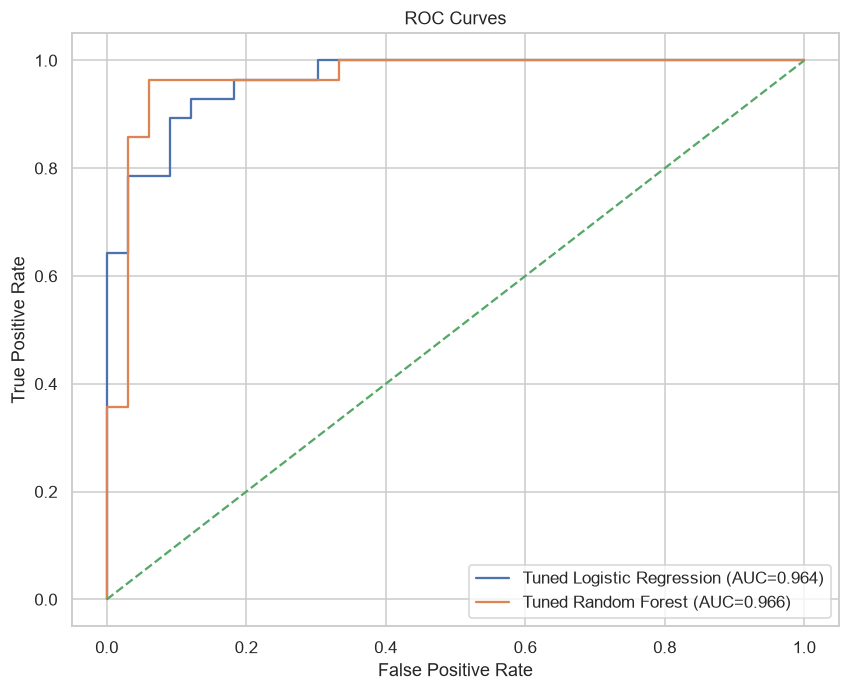

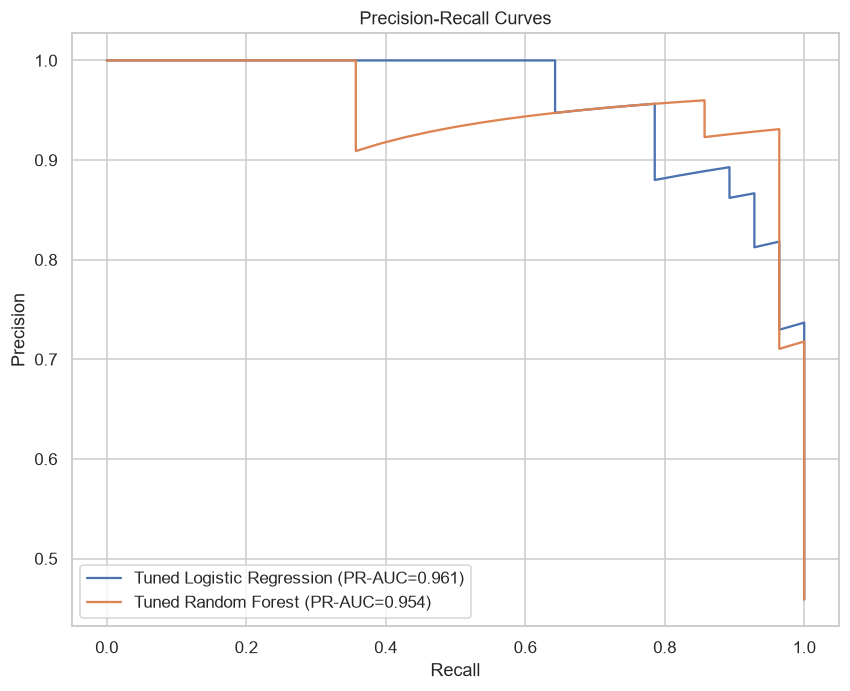

In [68]:
plt.figure(figsize=(9, 7))

for name, model in candidate_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

plt.figure(figsize=(9, 7))

for name, model in candidate_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

## 24. Threshold Optimization

Model used for threshold analysis: Tuned Logistic Regression
OOF F1-optimized threshold: 0.39


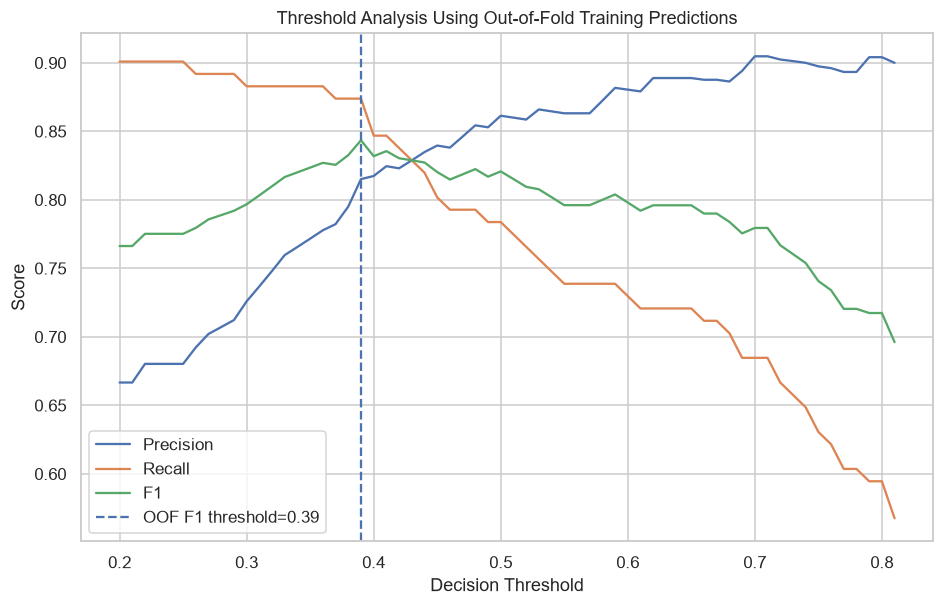

In [69]:
# Threshold tuning is performed on out-of-fold TRAINING probabilities.
# This avoids using the held-out test set to choose the decision threshold.

oof_prob = cross_val_predict(
    clone(threshold_model),
    X_train,
    y_train,
    cv=CV,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.01):
    pred = (oof_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_train, pred, zero_division=0),
        "recall": recall_score(y_train, pred, zero_division=0),
        "f1": f1_score(y_train, pred, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_rows)
best_threshold = float(
    threshold_results.loc[
        threshold_results["f1"].idxmax(), "threshold"
    ]
)

# Now fit the selected model on the training split and obtain untouched test probabilities.
threshold_model.fit(X_train, y_train)
threshold_prob = threshold_model.predict_proba(X_test)[:, 1]

print("Model used for threshold analysis:", threshold_model_name)
print("OOF F1-optimized threshold:", round(best_threshold, 2))

plt.figure(figsize=(10, 6))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"OOF F1 threshold={best_threshold:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis Using Out-of-Fold Training Predictions")
plt.legend()
plt.show()


## 25. Final Evaluation & Error Analysis

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



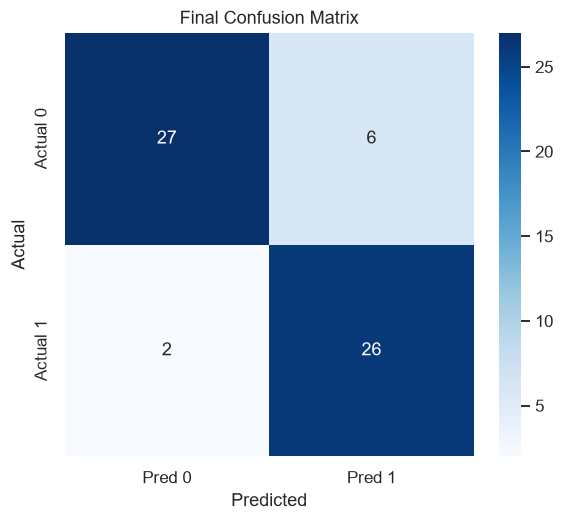

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,age_group,thalach_age_ratio,chol_age_ratio,bp_age_ratio,oldpeak_thalach_ratio,exercise_stress_index,cardio_burden,actual,probability,prediction,error_type
66,60.0000,1.0000,3.0000,140.0000,185.0000,0.0000,2.0000,155.0000,0.0000,3.0000,2.0000,0.0000,3.0000,2,2.5833,3.0833,2.3333,0.0194,3.0000,3.0000,1,0.2681,0,False Negative
172,59.0000,0.0000,4.0000,174.0000,249.0000,0.0000,0.0000,143.0000,1.0000,0.0000,2.0000,0.0000,3.0000,2,2.4237,4.2203,2.9492,0.0000,0.0000,1.0000,1,0.3539,0,False Negative
131,51.0000,1.0000,3.0000,94.0000,227.0000,0.0000,0.0000,154.0000,1.0000,0.0000,1.0000,1.0000,7.0000,2,3.0196,4.4510,1.8431,0.0000,0.0000,2.0000,0,0.4361,1,False Positive
287,58.0000,1.0000,2.0000,125.0000,220.0000,0.0000,0.0000,144.0000,0.0000,0.4000,2.0000,0.0000,7.0000,2,2.4828,3.7931,2.1552,0.0028,0.4000,0.4000,0,0.4641,1,False Positive
271,66.0000,1.0000,4.0000,160.0000,228.0000,0.0000,2.0000,138.0000,0.0000,2.3000,1.0000,0.0000,6.0000,3,2.0909,3.4545,2.4242,0.0167,2.3000,2.3000,0,0.5819,1,False Positive
33,59.0000,1.0000,4.0000,135.0000,234.0000,0.0000,0.0000,161.0000,0.0000,0.5000,2.0000,0.0000,7.0000,2,2.7288,3.9661,2.2881,0.0031,0.5000,0.5000,0,0.7295,1,False Positive
196,69.0000,1.0000,1.0000,160.0000,234.0000,1.0000,2.0000,131.0000,0.0000,0.1000,2.0000,1.0000,3.0000,3,1.8986,3.3913,2.3188,0.0008,0.1000,1.1000,0,0.7348,1,False Positive
92,62.0000,1.0000,3.0000,130.0000,231.0000,0.0000,0.0000,146.0000,0.0000,1.8000,2.0000,3.0000,7.0000,3,2.3548,3.7258,2.0968,0.0123,1.8000,4.8000,0,0.8786,1,False Positive


In [70]:
final_pred = (threshold_prob >= best_threshold).astype(int)

print(classification_report(
    y_test,
    final_pred,
    target_names=["No Disease", "Disease"],
    zero_division=0
))

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

error_analysis = X_test.copy()
error_analysis["actual"] = y_test.values
error_analysis["probability"] = threshold_prob
error_analysis["prediction"] = final_pred

error_analysis["error_type"] = np.select(
    [
        (error_analysis["actual"] == 0) & (error_analysis["prediction"] == 1),
        (error_analysis["actual"] == 1) & (error_analysis["prediction"] == 0)
    ],
    ["False Positive", "False Negative"],
    default="Correct"
)

display(
    error_analysis[
        error_analysis["error_type"] != "Correct"
    ].sort_values("probability")
)

## 26. Probability Calibration

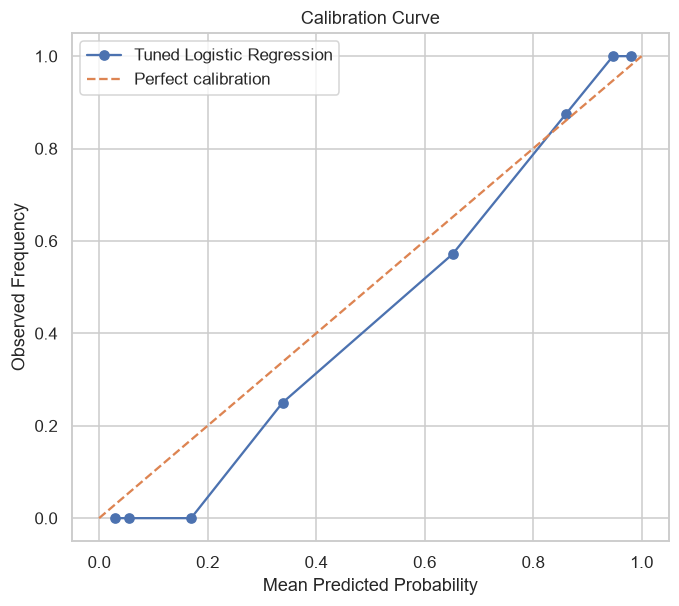

Brier score: 0.08026302840905156


In [71]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test, threshold_prob, n_bins=8, strategy="quantile"
)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", label=threshold_model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.show()

print("Brier score:", brier_score_loss(y_test, threshold_prob))

## 27. Explainability — Permutation Importance

,feature,importance_mean,importance_std
2,cp,0.0507,0.0160
11,ca,0.0406,0.0156
18,exercise_stress_index,0.0268,0.0075
19,cardio_burden,0.0096,0.0057
12,thal,0.0076,0.0084
10,slope,0.0074,0.0073
1,sex,0.0068,0.0071
3,trestbps,0.0052,0.0068
7,thalach,0.0045,0.0063
6,restecg,0.0022,0.0031


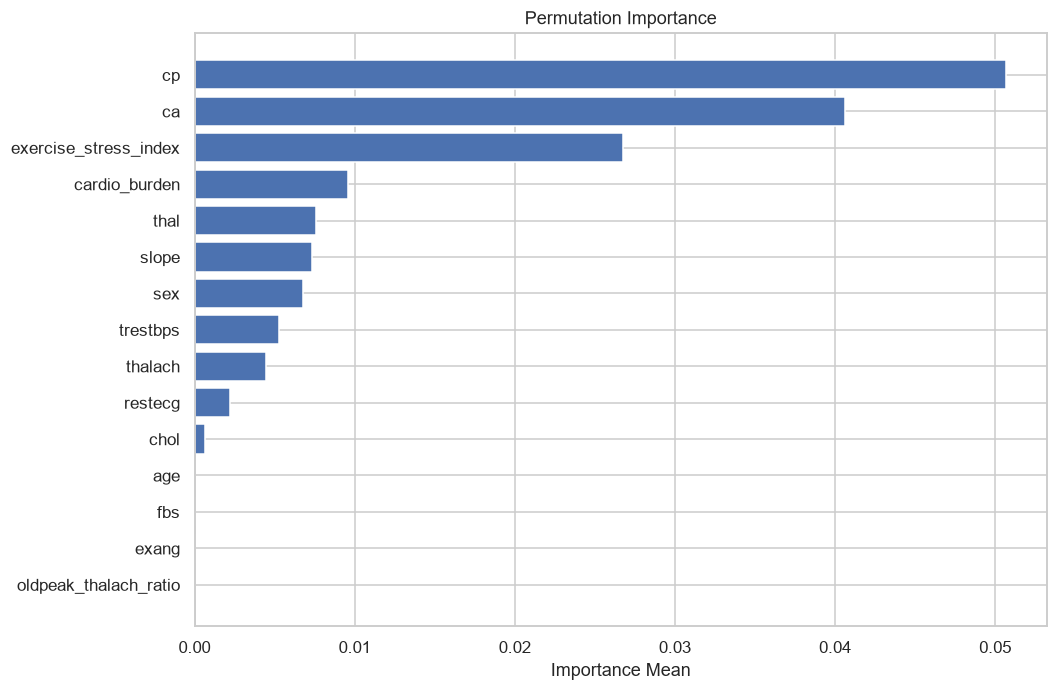

In [72]:
perm = permutation_importance(
    threshold_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_results = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

display(perm_results)

plt.figure(figsize=(10, 7))
perm_plot = perm_results.head(15).sort_values("importance_mean")
plt.barh(perm_plot["feature"], perm_plot["importance_mean"])
plt.xlabel("Importance Mean")
plt.title("Permutation Importance")
plt.show()

## 28. Optional SHAP Explainability

In [73]:
try:
    import shap

    # SHAP is applied to a fitted tree model when available.
    shap_model = random_search.best_estimator_

    transformed_train = shap_model.named_steps["preprocess"].transform(X_train)
    transformed_test = shap_model.named_steps["preprocess"].transform(X_test)

    feature_names = shap_model.named_steps["preprocess"].get_feature_names_out()

    explainer = shap.TreeExplainer(shap_model.named_steps["model"])
    shap_values = explainer.shap_values(transformed_test)

    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values

    shap.summary_plot(
        shap_values_plot,
        transformed_test,
        feature_names=feature_names,
        show=True
    )
except Exception as e:
    print("SHAP analysis skipped:", e)

SHAP analysis skipped: No module named 'shap'


## 29. Unsupervised Learning — K-Means

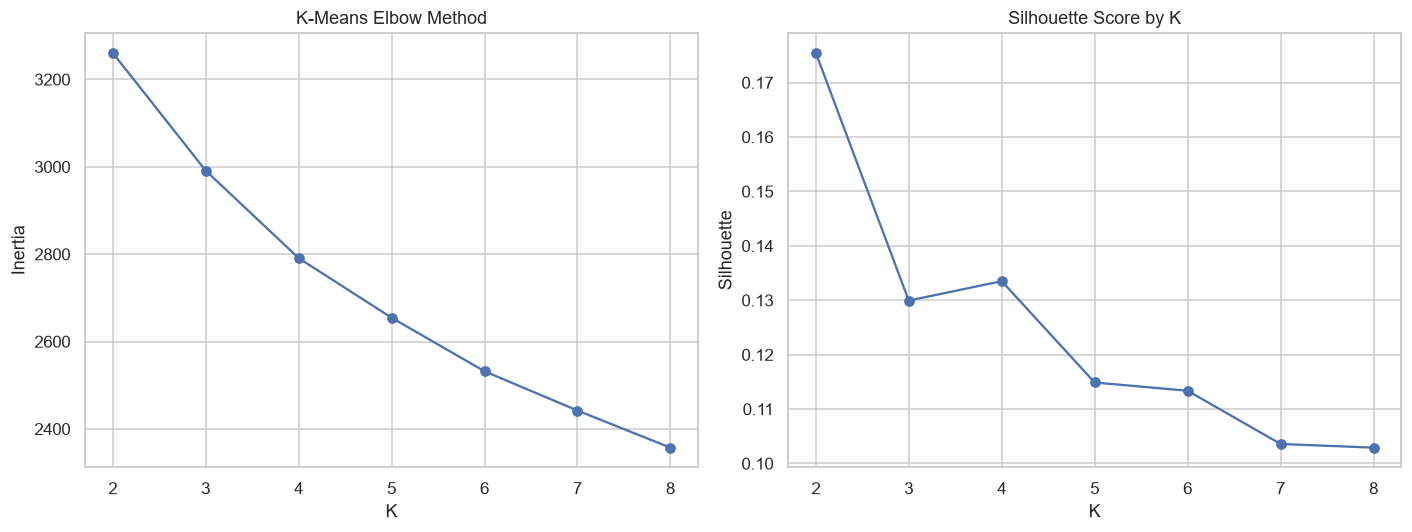

K selected by silhouette score: 2
Silhouette: 0.1754707279030596
Davies-Bouldin: 2.081444930715181
Calinski-Harabasz: 62.602162573932645
Adjusted Rand Index vs target: 0.43808577271698784


In [74]:
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(X[numeric_features])

inertias = []
silhouettes = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_cluster)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(2, 9), inertias, marker="o")
axes[0].set_title("K-Means Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(range(2, 9), silhouettes, marker="o")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

best_k = int(np.argmax(silhouettes) + 2)
print("K selected by silhouette score:", best_k)

kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_cluster)

print("Silhouette:", silhouette_score(X_cluster, cluster_labels))
print("Davies-Bouldin:", davies_bouldin_score(X_cluster, cluster_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(X_cluster, cluster_labels))
print("Adjusted Rand Index vs target:", adjusted_rand_score(y, cluster_labels))

## 30. Cluster Profiles

In [75]:
clustered = df.copy()
clustered["cluster"] = cluster_labels

cluster_profile = clustered.groupby("cluster")[numeric_features + [TARGET]].mean().round(3)
display(cluster_profile)

cluster_sizes = clustered["cluster"].value_counts().sort_index()
display(cluster_sizes.rename("cluster_size").to_frame())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
cluster,,,,,,,,,,,,,,
0,58.2280,0.8160,3.7720,134.9650,254.6670,0.1930,1.2190,132.9470,0.6750,1.8750,1.9650,1.2540,6.1670,0.8860
1,52.1530,0.5980,2.7880,129.7140,241.8840,0.1220,0.8520,159.6560,0.1160,0.5360,1.3810,0.3070,3.8520,0.2010


,cluster_size
cluster,
0,114
1,189


## 31. Hierarchical Clustering

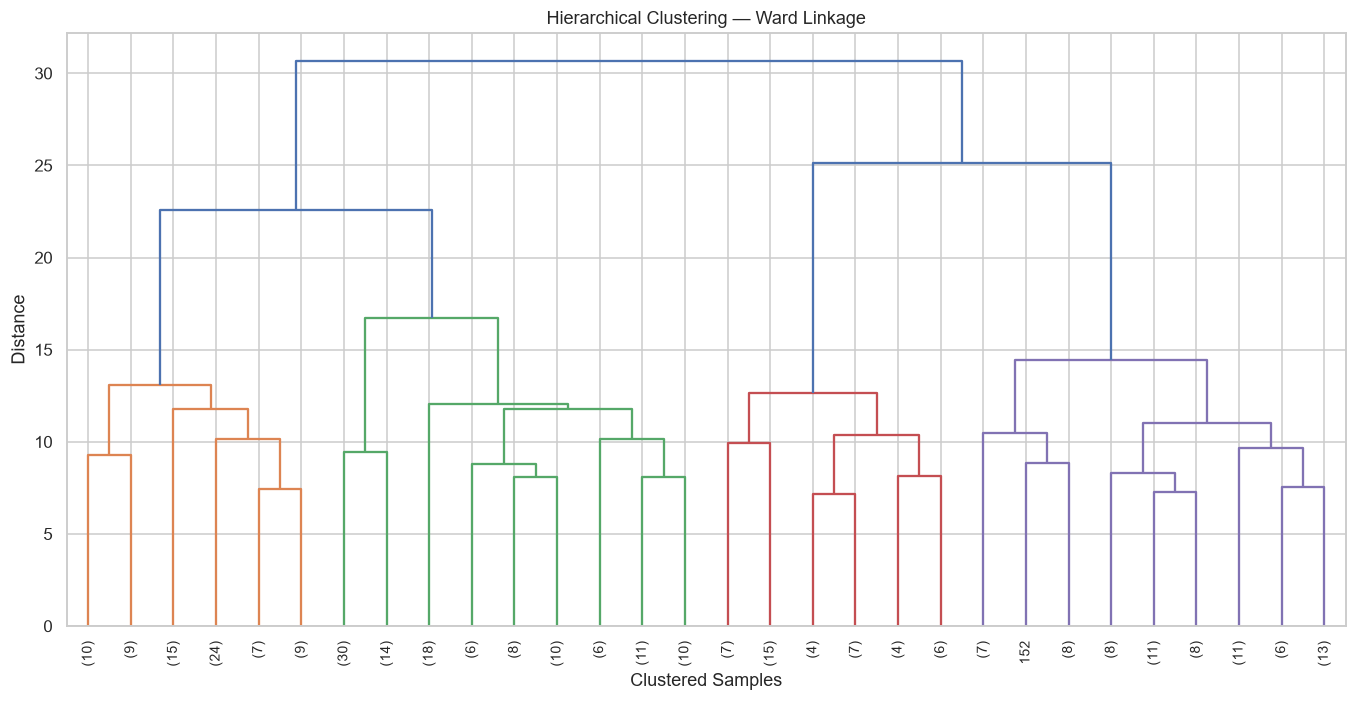

Hierarchical silhouette: 0.13892313671391457
Hierarchical ARI vs target: 0.146129913123814


In [76]:
Z = linkage(X_cluster, method="ward")

plt.figure(figsize=(15, 7))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9
)
plt.title("Hierarchical Clustering — Ward Linkage")
plt.xlabel("Clustered Samples")
plt.ylabel("Distance")
plt.show()

hier_labels = fcluster(Z, t=best_k, criterion="maxclust") - 1

print(
    "Hierarchical silhouette:",
    silhouette_score(X_cluster, hier_labels)
)

print(
    "Hierarchical ARI vs target:",
    adjusted_rand_score(y, hier_labels)
)

## 32. Robustness & Stability Across Random Seeds

In [77]:
stability_rows = []

for seed in [7, 21, 42, 84, 123]:
    cv_seed = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            C=grid_search.best_params_["model__C"],
            penalty=grid_search.best_params_["model__penalty"],
            solver="liblinear",
            max_iter=4000,
            random_state=seed
        ))
    ])

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv_seed,
        scoring=["accuracy", "f1", "roc_auc"],
        n_jobs=-1
    )

    stability_rows.append({
        "seed": seed,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean()
    })

stability_results = pd.DataFrame(stability_rows)
display(stability_results)

display(
    stability_results.drop(columns="seed")
    .agg(["mean", "std"])
)

,seed,accuracy_mean,f1_mean,roc_auc_mean
0,7,0.8384,0.8153,0.9033
1,21,0.7969,0.7752,0.8861
2,42,0.8430,0.8209,0.9058
3,84,0.8264,0.8013,0.8835
4,123,0.8429,0.8198,0.9002


,accuracy_mean,f1_mean,roc_auc_mean
mean,0.8295,0.8065,0.8958
std,0.0194,0.0192,0.0103


## 33. Final Model Comparison Dashboard

In [78]:
final_dashboard = candidate_results.merge(
    candidate_cv_results,
    on="Model",
    how="left"
)

display(
    final_dashboard[
        [
            "Model", "CV ROC-AUC Mean", "CV ROC-AUC Std",
            "CV F1 Mean", "CV PR-AUC Mean",
            "Accuracy", "Precision", "Recall",
            "F1", "ROC-AUC", "PR-AUC", "Brier"
        ]
    ].sort_values("CV ROC-AUC Mean", ascending=False)
)

print("Selection principle: highest mean CV ROC-AUC on training data.")
print("Test-set metrics are reported only after model selection.")


,Model,CV ROC-AUC Mean,CV ROC-AUC Std,CV F1 Mean,CV PR-AUC Mean,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,Tuned Logistic Regression,0.9054,0.0099,0.8209,0.9025,0.9016,0.8667,0.9286,0.8966,0.9643,0.9608,0.0803
1,Tuned Random Forest,0.8881,0.0242,0.7823,0.8839,0.9180,0.8710,0.9643,0.9153,0.9665,0.9538,0.0944


Selection principle: highest mean CV ROC-AUC on training data.
Test-set metrics are reported only after model selection.


## 34. Reproducible Final Pipeline & Artifact Export

In [79]:
# Reproducible deployment pipeline:
# raw input -> feature engineering -> preprocessing -> trained model.
# The threshold is kept separately because sklearn predict() uses 0.50 by default.

deployment_model = clone(threshold_model.named_steps["model"])

deployment_pipeline = Pipeline([
    ("feature_engineering", FunctionTransformer(add_engineered_features, validate=False)),
    ("preprocess", preprocessor),
    ("model", deployment_model)
])

deployment_pipeline.fit(X, y)

artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

joblib.dump(
    deployment_pipeline,
    artifact_dir / "final_pipeline.pkl"
)

metadata = {
    "dataset": str(DATA_PATH),
    "target": TARGET,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "threshold": float(best_threshold),
    "model_name": threshold_model_name,
    "project_final_features": PROJECT_FINAL_FEATURES,
    "stable_features": stable_features,
    "feature_engineering": engineered_columns,
    "schema": list(df.columns),
    "threshold_tuning": "out-of-fold training probabilities",
    "deployment_training": "full dataset after final evaluation"
}

with open(artifact_dir / "feature_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

metrics = {
    "model": threshold_model_name,
    "threshold": float(best_threshold),
    "accuracy": float(accuracy_score(y_test, final_pred)),
    "precision": float(precision_score(y_test, final_pred, zero_division=0)),
    "recall": float(recall_score(y_test, final_pred, zero_division=0)),
    "f1": float(f1_score(y_test, final_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, threshold_prob)),
    "pr_auc": float(average_precision_score(y_test, threshold_prob)),
    "brier_score": float(brier_score_loss(y_test, threshold_prob))
}

with open(artifact_dir / "model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

predictions = X_test.copy()
predictions["actual"] = y_test.values
predictions["probability"] = threshold_prob
predictions["prediction"] = final_pred
predictions["threshold"] = best_threshold

predictions.to_csv(
    artifact_dir / "predictions.csv",
    index=False
)

print("Artifacts exported to:", artifact_dir.resolve())
print(json.dumps(metrics, indent=2))


Artifacts exported to: C:\Users\noura\Z3-Heart_Disease_Prediction\artifacts
{
  "model": "Tuned Logistic Regression",
  "threshold": 0.3900000000000002,
  "accuracy": 0.8688524590163934,
  "precision": 0.8125,
  "recall": 0.9285714285714286,
  "f1": 0.8666666666666667,
  "roc_auc": 0.9642857142857144,
  "pr_auc": 0.9607678625903535,
  "brier_score": 0.08026302840905156
}


## 35. Final Project Summary

In [80]:
print("ADVANCED PROJECT SUMMARY")
print("=" * 60)
print(f"Dataset shape: {df.shape}")
print(f"Target balance: {y.mean():.2%} positive class")
print(f"Stable features: {stable_features}")
print(f"Existing project features: {PROJECT_FINAL_FEATURES}")
print(f"PCA components for 95% variance: {n_components_95}")
print(f"Final model: {threshold_model_name}")
print(f"Optimized threshold: {best_threshold:.2f}")
print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
print(f"PR-AUC: {metrics['pr_auc']:.4f}")
print(f"F1: {metrics['f1']:.4f}")
print(f"Brier score: {metrics['brier_score']:.4f}")

ADVANCED PROJECT SUMMARY
Dataset shape: (303, 14)
Target balance: 45.87% positive class
Stable features: ['ca', 'oldpeak', 'cp', 'thal', 'exang', 'slope', 'sex']
Existing project features: ['thalach', 'thal', 'cp', 'ca', 'oldpeak']
PCA components for 95% variance: 12
Final model: Tuned Logistic Regression
Optimized threshold: 0.39
ROC-AUC: 0.9643
PR-AUC: 0.9608
F1: 0.8667
Brier score: 0.0803


## 36. Scientific Interpretation & Limitations

### What this project now demonstrates

- Deep exploratory analysis rather than only basic plots.
- Statistical feature-signal analysis using ANOVA, chi-square, Cramér's V, and mutual information.
- Multicollinearity inspection.
- Feature engineering with a controlled comparison workflow.
- Leakage-safe preprocessing using `Pipeline` and `ColumnTransformer`.
- PCA with explained-variance analysis and component loadings.
- Filter, wrapper, and embedded feature-selection methods.
- Feature-selection stability across methods.
- Multiple supervised learning algorithms.
- Stratified cross-validation with multiple evaluation metrics.
- Grid and randomized hyperparameter optimization.
- Imbalance experiments with class weights and optional SMOTE variants.
- ROC-AUC, PR-AUC, calibration, Brier score, and threshold analysis.
- False-positive / false-negative error analysis.
- Permutation importance and optional SHAP explainability.
- K-Means and hierarchical clustering with multiple cluster-quality metrics.
- Stability testing across multiple random seeds.
- Reproducible model and metadata artifacts.

### Important limitations

This dataset is relatively small, so individual test-set metrics can vary noticeably with the split. Cross-validation and stability analysis are therefore important.

The variables are encoded according to the supplied cleaned dataset. Numeric-looking clinical codes such as `cp`, `thal`, and `slope` are treated as categorical during modeling where appropriate.

The project is for educational/research purposes only and should not be interpreted as a clinically validated diagnostic model.